# Coupled chains
Energy diffusion in MFTFI on Ly possibly coupled chains

In [1]:
import sys
sys.path.append('../')
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from qiskit.quantum_info import SparsePauliOp
import matplotlib.pyplot as plt
import pickle
import time
from pympler import asizeof

In [2]:
gx = 1.4
gz = 0.9045
Lx = 51
Ly = 4
nsites = Lx * Ly
periodic = True
eta = 1.0 # chain coupling
hx = SparsePauliOp.from_sparse_list([('X', [i], gx) for i in range(nsites)], num_qubits=nsites)
hz = SparsePauliOp.from_sparse_list([('Z', [i], gz) for i in range(nsites)], num_qubits=nsites)
hzz_h = SparsePauliOp.from_sparse_list([('ZZ', [i*Ly + j, (i+1)*Ly + j], 1.0) for i in range(Lx-1) for j in range(Ly) ], num_qubits=nsites)
hzz_v = SparsePauliOp.from_sparse_list([('ZZ', [i*Ly + j, i*Ly + (j + 1) % Ly], 1.0 * eta) for i in range(Lx) for j in range(Ly - (not periodic)) ], num_qubits=nsites)

hi = []
for i in range(Lx):
    hix = hx[i*Ly:(i+1)*Ly]
    hiz = hz[i*Ly:(i+1)*Ly]
    hizz_v = hzz_v[i*(Ly - (not periodic)):(i+1)*(Ly - (not periodic))]
    if i == 0:
        hizz_h = hzz_h[i*Ly:(i+1)*Ly]/2
        pass
    elif i == Lx-1:
        hizz_h = hzz_h[(i-1)*Ly:i*Ly]/2
    else:
        hizz_h = hzz_h[i*Ly:(i+1)*Ly]/2 + hzz_h[(i-1)*Ly:i*Ly]/2
    hii = hix + hiz + hizz_v + hizz_h
    hi.append(sum(hii))
#hi = [hx[0] + hz[0] + hzz[0]/2] + [hx[i] + hz[i] + hzz[i-1] / 2 + hzz[i] / 2 for i in range(1, nsites-1)] + [hx[nsites-1] + hz[nsites-1] + hzz[nsites-2]/2]

def exp_val_func(observable):
    return [observable.overlap(PauliRepresentation.from_sparse_pauli_op(h)) for h in hi], observable.size

def msd(a):
    j = np.arange(1,len(a)+1) - len(a)//2
    return np.sum(a*j**2) - np.sum(a*j)**2

In [3]:
hi[0]

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIX', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

In [4]:
hi[(Lx-1)//2].size

20

In [20]:
dt = 0.01
nsteps = 80
#threshold_factor = 10
ops = dt*(hz + hzz_h + hzz_v + hx)
#ops = dt/2*(hz + hx) + dt*(hzz_h + hzz_v) + dt/2*(hz + hx)
obs = hi[(Lx-1)//2]

In [21]:
for threshold_factor in [10]:#, 7, 8, 9, 10]:
    print(threshold_factor)
    start = time.time()
    sim = Simulation.from_pauli_list(obs, ops, threshold=2**(-threshold_factor), nprocs=32)
    r, norm = sim.run_dynamics(nsteps, process=exp_val_func, process_every = 10, status_report=True)
    num_strings = [ri[1] for ri in r]
    C = [ri[0] for ri in r]
    C = np.array(C)
    C_norm = C / C[0].sum()
    print(num_strings[-1], np.max(num_strings), C_norm.sum(axis=1)[-1], 
          np.linalg.norm(sim.observable.coeffs)/np.linalg.norm(obs.coeffs), time.time() - start)
    d2 = [msd(ri) for ri in C_norm]
    
    #with open(f"L{nsites}_gx{gx}_gz{gz}_threshold{threshold_factor}_dt{dt}_nsteps{nsteps}.pkl", "wb") as f:
    #    pickle.dump({'num_strings': num_strings, 'C_norm': r, 'norm': norm}, f)

10
Step 10: number of strings - 112, norm - 0.9999925353560107, time - 2.6307730674743652
Step 20: number of strings - 256, norm - 0.9999585334493625, time - 2.7169179916381836
Step 30: number of strings - 420, norm - 0.9998999941076547, time - 2.8203303813934326
Step 40: number of strings - 1008, norm - 0.9997335347970115, time - 3.038909435272217
Step 50: number of strings - 1970, norm - 0.9993987750281085, time - 3.2114598751068115
Step 60: number of strings - 2971, norm - 0.998750320755574, time - 3.5482826232910156
Step 70: number of strings - 4772, norm - 0.9975939963831877, time - 3.9890053272247314
Step 80: number of strings - 6965, norm - 0.9958808647573498, time - 4.593999147415161
6965 6965 (0.9851130654086994+0j) 0.9958808647573498 26.55670952796936


In [22]:
d2

[(0.10464366190867636+0j),
 (0.11277414216215587+0j),
 (0.13539804705960623+0j),
 (0.16764484302585358+0j),
 (0.21281392184094083+0j),
 (0.26511317908550536+0j),
 (0.31488805592465996+0j),
 (0.3661519671098403+0j),
 (0.4291695369019062+0j)]

In [15]:
obs.coeffs

array([1.4   +0.j, 1.4   +0.j, 1.4   +0.j, 1.4   +0.j, 0.9045+0.j,
       0.9045+0.j, 0.9045+0.j, 0.9045+0.j, 1.    +0.j, 1.    +0.j,
       1.    +0.j, 1.    +0.j, 0.5   +0.j, 0.5   +0.j, 0.5   +0.j,
       0.5   +0.j, 0.5   +0.j, 0.5   +0.j, 0.5   +0.j, 0.5   +0.j])

In [16]:
r, norm = sim.run_dynamics(nsteps, process=exp_val_func, process_every = 10, status_report=True, r = r, norm = norm, start=40)

Step 50: number of strings - 1970, norm - 0.9993987750281085, time - 3.521540641784668
Step 60: number of strings - 2971, norm - 0.998750320755574, time - 3.6306118965148926
Step 70: number of strings - 4772, norm - 0.9975939963831877, time - 3.828169345855713
Step 80: number of strings - 6965, norm - 0.9958808647573498, time - 4.859821081161499


In [17]:
norm

[1.0,
 0.9999925353560107,
 0.9999585334493625,
 0.9998999941076547,
 0.9997335347970115,
 0.9993987750281085,
 0.998750320755574,
 0.9975939963831877,
 0.9958808647573498]

In [19]:
num_strings = [ri[1] for ri in r]
C = [ri[0] for ri in r]
C = np.array(C)
C_norm = C / C[0].sum()
print(num_strings[-1], np.max(num_strings), C_norm.sum(axis=1)[-1], 
      np.linalg.norm(sim.observable.coeffs)/np.linalg.norm(obs.coeffs), time.time() - start)
d2 = [msd(ri) for ri in C_norm]
print(d2)

6965 6965 (0.9851130654086994+0j) 0.9958808647573498 448.3694462776184
[(0.10464366190867636+0j), (0.11277414216215587+0j), (0.13539804705960623+0j), (0.16764484302585358+0j), (0.21281392184094083+0j), (0.26511317908550536+0j), (0.31488805592465996+0j), (0.3661519671098403+0j), (0.4291695369019062+0j)]


In [ ]:
sim = Simulation.from_pauli_list(obs, ops, threshold=2**(-threshold_factor), nprocs=32)
r, norm = sim.run_dynamics(20, process=exp_val_func, process_every = 10, status_report=True)
r, norm = sim.run_dynamics(20, process=exp_val_func, process_every = 10, status_report=True, r=r, norm=norm, start=20)

num_strings = [ri[1] for ri in r]
r = [ri[0] for ri in r]
r = np.array(r)
r = r / r[0].sum()
print(num_strings[-1], np.max(num_strings), r.sum(axis=1)[-1], 
      np.linalg.norm(sim.observable.coeffs)/np.linalg.norm(obs.coeffs), time.time() - start)
d2 = [msd(ri) for ri in r]

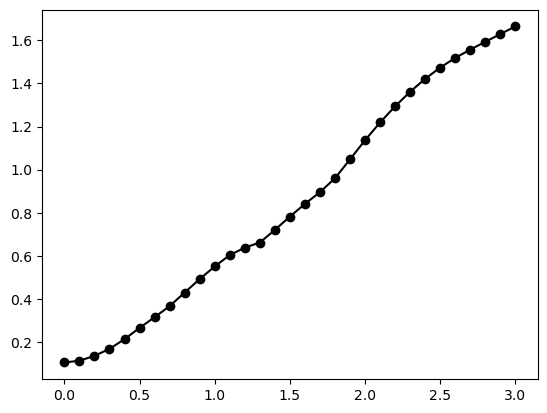

In [64]:
fig, ax = plt.subplots(1, 1)
ax.plot(np.arange(len(d2))/10, abs(np.array(d2)), '-ok')
#ax.set_ylim(0, 7)
plt.show()

In [27]:
d2_13 = d2

In [34]:
d2_16 = d2